# Word/Line-level TrOCR — Kaggle GPU Training (document OCR)

Fine-tunes `microsoft/trocr-base-handwritten` on **synthetic Nepali WORD images** so the model can read joined handwriting **with matras/conjuncts/punctuation** — unlike the single-character CRNN/TrOCR.

**No dataset attachment needed** — the synthetic data is generated inside this notebook.

Settings panel: **Accelerator = GPU T4**, **Internet = ON** (needed to clone the repo, apt-get Devanagari fonts, and download the pretrained TrOCR weights).

Run all cells top to bottom. Trained weights + logs land in `/kaggle/working/artifacts`.

Code: repo branch `ml` (push your latest work there first).

In [1]:
# 1. Confirm GPU is on
import torch
assert torch.cuda.is_available(), 'No GPU! Settings -> Accelerator -> GPU T4'
print(torch.cuda.get_device_name(0))

Tesla T4


In [2]:
# 2. Get the code (branch: ml). transformers/torchvision/Pillow are preinstalled on Kaggle.
import os
if not os.path.isdir('/kaggle/working/Devnagari_Handwriting_Recognition'):
    !git clone -b ml https://github.com/Sanskriti-poudel/Devnagari_Handwriting_Recognition.git /kaggle/working/Devnagari_Handwriting_Recognition
%cd /kaggle/working/Devnagari_Handwriting_Recognition
!git log --oneline -1

Cloning into '/kaggle/working/Devnagari_Handwriting_Recognition'...
remote: Enumerating objects: 294, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 294 (delta 6), reused 31 (delta 5), pack-reused 244 (from 1)
Receiving objects: 100% (294/294), 89.24 MiB | 41.88 MiB/s, done.
Resolving deltas: 100% (83/83), done.
/kaggle/working/Devnagari_Handwriting_Recognition
46f8713 (HEAD -> ml, origin/ml) Wire word-level TrOCR into webapp document mode for mid-defense demo


In [3]:
# 3. Install Devanagari fonts (Kaggle is Linux — no Nirmala/Mangal). The generator
#    auto-detects these once installed. Without them it renders empty boxes.
!apt-get -qq update && apt-get -qq install -y fonts-deva fonts-lohit-deva fonts-indic fonts-noto-core > /dev/null 2>&1
import glob
found = [f for f in glob.glob('/usr/share/fonts/**/*.ttf', recursive=True)
         if any(k in os.path.basename(f).lower() for k in ['devanagari','lohit-deva','gargi','samanata','kalimati','nakula','sahadeva'])]
print(f'{len(found)} Devanagari font file(s) found, e.g.:')
for f in found[:8]:
    print('  ', f)
assert found, 'No Devanagari fonts installed — check Internet is ON and apt-get succeeded.'

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
11 Devanagari font file(s) found, e.g.:
   /usr/share/fonts/truetype/fonts-deva-extra/samanata.ttf
   /usr/share/fonts/truetype/fonts-deva-extra/kalimati.ttf
   /usr/share/fonts/truetype/Sahadeva/sahadeva.ttf
   /usr/share/fonts/truetype/Gargi/Gargi.ttf
   /usr/share/fonts/truetype/samyak/Samyak-Devanagari.ttf
   /usr/share/fonts/truetype/Nakula/nakula.ttf
   /usr/share/fonts/truetype/lohit-devanagari/Lohit-Devanagari.ttf
   /usr/share/fonts/truetype/noto/NotoSerifDevanagari-Regular.ttf


In [4]:
# 4. Generate the synthetic training set (mixed real Nepali words + random syllables).
#    ~8k images is a reasonable first pretrain; bump --n for more. Fast (CPU, a few min).
!python data/generate_synth.py --out Datasets/synth --n 8000 --real-ratio 0.5 --seed 42
import os
print('images:', len(os.listdir('Datasets/synth/images')), '| labels.csv exists:', os.path.exists('Datasets/synth/labels.csv'))

[fonts] 15 font file(s): ['/usr/share/fonts/truetype/fonts-deva-extra/samanata.ttf', '/usr/share/fonts/truetype/fonts-deva-extra/chandas1-2.ttf', '/usr/share/fonts/truetype/fonts-deva-extra/kalimati.ttf', '/usr/share/fonts/truetype/Sahadeva/sahadeva.ttf', '/usr/share/fonts/truetype/Gargi/Gargi.ttf', '/usr/share/fonts/truetype/fonts-beng-extra/Muktibold.ttf', '/usr/share/fonts/truetype/fonts-beng-extra/Mukti.ttf', '/usr/share/fonts/truetype/Sarai/Sarai.ttf', '/usr/share/fonts/truetype/samyak/Samyak-Devanagari.ttf', '/usr/share/fonts/truetype/Nakula/nakula.ttf', '/usr/share/fonts/truetype/lohit-devanagari/Lohit-Devanagari.ttf', '/usr/share/fonts/truetype/noto/NotoSerifDevanagari-Regular.ttf', '/usr/share/fonts/truetype/noto/NotoSerifDevanagari-Bold.ttf', '/usr/share/fonts/truetype/noto/NotoSansDevanagari-Regular.ttf', '/usr/share/fonts/truetype/noto/NotoSansDevanagari-Bold.ttf']
[fonts] 60 (font,size) variants
[gen] 8000 images, real_ratio=0.5, clean_ratio=0.25, seed=42
  500/8000
  1000

/tmp/ipykernel_24/4277321020.py:10: UserWarning: Glyph 2361 (\N{DEVANAGARI LETTER HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_24/4277321020.py:10: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_24/4277321020.py:10: UserWarning: Glyph 2367 (\N{DEVANAGARI VOWEL SIGN I}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_24/4277321020.py:10: UserWarning: Glyph 2350 (\N{DEVANAGARI LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_24/4277321020.py:10: UserWarning: Glyph 2366 (\N{DEVANAGARI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_24/4277321020.py:10: UserWarning: Glyph 2354 (\N{DEVANAGARI LETTER LA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_24/4277321020.py:10: UserWarning: Glyph 2360 (\N{DEVANAGARI LETTER 

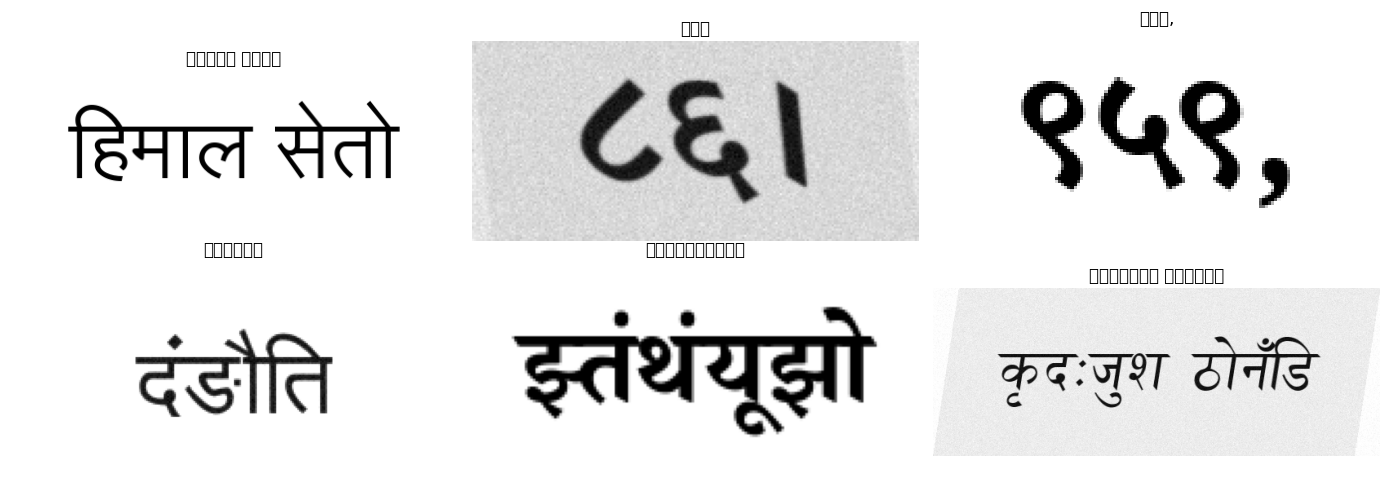

In [5]:
# 4b. SANITY: eyeball a few generated images + labels. The glyphs must render as
#     real Devanagari (not tofu boxes). If you see boxes, the font install failed.
import csv, matplotlib.pyplot as plt
from PIL import Image
rows = list(csv.DictReader(open('Datasets/synth/labels.csv', encoding='utf-8')))[:6]
fig, axes = plt.subplots(2, 3, figsize=(14, 5))
for ax, r in zip(axes.ravel(), rows):
    ax.imshow(Image.open(os.path.join('Datasets/synth', r['image_path'])), cmap='gray')
    ax.set_title(r['text']); ax.axis('off')
plt.tight_layout(); plt.show()

In [6]:
# 5. Fine-tune the WORD-level TrOCR on the synthetic data.
#    batch_size=4 fits trocr-base on a 16GB T4 (drop to 2 if OOM). Output tee'd to a log.
#    Weights -> models/trocr/checkpoints_words (separate from the single-char checkpoint).
#    Knobs: TROCR_BATCH_SIZE, TROCR_EPOCHS, TROCR_LR, TROCR_NUM_WORKERS.
import os
os.environ['TROCR_BATCH_SIZE'] = '4'
os.environ['TROCR_EPOCHS'] = '6'
os.environ['TROCR_NUM_WORKERS'] = '2'
os.makedirs('/kaggle/working/artifacts', exist_ok=True)
!python -u models/trocr/train_words.py --labels Datasets/synth/labels.csv 2>&1 | tee /kaggle/working/artifacts/train_words.log

[trocr-words] device=cuda model=microsoft/trocr-base-handwritten batch=4 epochs=6 labels=Datasets/synth/labels.csv
The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100%|██████████| 478/478 [00:00<00:00, 1615.15it/s, Materializing param=encoder.layernorm.weight]
VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[trocr-words] parameters: 333,921,792
[WordLineDataset] 800 items
[WordLineDataset]

In [7]:
# 5b. SANITY: run the trained model on a few held-out synthetic lines. Predictions
#     should be real multi-glyph Devanagari close to the ground truth (not empty/garbage).
import sys, csv, os
sys.path.insert(0, 'models/trocr'); sys.path.insert(0, '.')
os.environ['TROCR_WORDS_CHECKPOINT'] = 'models/trocr/checkpoints_words'
from predict_words import predict_line
rows = list(csv.DictReader(open('Datasets/synth/labels.csv', encoding='utf-8')))[-6:]
for r in rows:
    out = predict_line(os.path.join('Datasets/synth', r['image_path']))
    print(f"gt={r['text']!r:30} pred={out['text']!r:30} conf={out['confidence']}")

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

gt='आठ कलेज,'                     pred='आठ कलेड़,,'                    conf=0.8372
gt='पोखरा सै'                     pred='पोखरा सै'                     conf=0.9118
gt='४ मृत्यु धरान काठमाडौं'       pred='४ृःततऍयँधधननककमाममममईई'       conf=0.5589
gt='दू नर्स रोटीखःशः'             pred='दू नरर॰॰य़टटखःःःः'             conf=0.7183
gt='सात'                          pred='सातत'                         conf=0.9122
gt='इणेबीथा यातायात।'             pred='इइइब६थथााययययाततत'            conf=0.6844


In [8]:
# 6. Save the trained weights + logs to /kaggle/working/artifacts so they download
#    with the notebook version. Download the artifacts/ folder afterwards.
import shutil, os
os.makedirs('/kaggle/working/artifacts', exist_ok=True)
if os.path.exists('logs/trocr_words_training.csv'):
    shutil.copy('logs/trocr_words_training.csv', '/kaggle/working/artifacts/')
if os.path.isdir('models/trocr/checkpoints_words'):
    shutil.copytree('models/trocr/checkpoints_words',
                    '/kaggle/working/artifacts/checkpoints_words', dirs_exist_ok=True)
    print('saved checkpoint dir')
print(os.listdir('/kaggle/working/artifacts'))

saved checkpoint dir
['train_words.log', 'trocr_words_training.csv', 'checkpoints_words']
